# **SaaS Customer Churn Prediction and Early Warning Retention System**

**Model Inference and Prediction Pipeline**

> **Overview:** This file handles the inference phase of the project. It loads the pre-trained model artifacts and preprocessing pipelines exported from `utils.py`, processes new or unseen dataset samples, and generates churn predictions.

In [ ]:
import pandas as pd
import joblib

import sys
sys.path.append(r"D:\Enterprise Customer Intelligence and Support Ecosystem\SaaS_Churn_Project\src")

import utilis

In [3]:
def model_testing_on(file_path: str, model_path: str ):
    print(f"Target File Path received: {file_path}")
    
    df = pd.read_csv(file_path)
    print(f"Data loaded successfully. Shape: {df.shape}")
    
    return df

In [ ]:
df = model_testing_on(r"D:\Enterprise Customer Intelligence and Support Ecosystem\SaaS_Churn_Project\data\messy_customer_data.csv", r"D:\SaaS_Churn_Project\model\churn_model_pipeline.pkl")

Target File Path received: D:\SaaS_Churn_Project\data\messy_customer_data.csv
Data loaded successfully. Shape: (10000, 12)


In [ ]:
cln = utilis.DataCleaner(r"D:\Enterprise Customer Intelligence and Support Ecosystem\SaaS_Churn_Project\data\messy_customer_data.csv")
cln_df = cln.run_cleaning_pipeline()

Dataset loaded successfully!
--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          7621 non-null   str    
 1   Name                8342 non-null   str    
 2   Gender              7545 non-null   str    
 3   Age                 7424 non-null   float64
 4   City                8870 non-null   str    
 5   Signup_Date         7471 non-null   str    
 6   Last_purchase_date  6714 non-null   str    
 7   purchase_amount     4967 non-null   float64
 8   feedback_score      7538 non-null   float64
 9   email               4934 non-null   str    
 10  Phone_number        7556 non-null   str    
 11  Country             8296 non-null   str    
dtypes: float64(3), str(9)
memory usage: 1.4 MB
None

--- First 5 Rows of Data ---


,CustomerID,Name,Gender,Age,City,Signup_Date,Last_purchase_date,purchase_amount,feedback_score,email,Phone_number,Country
0,NaN,Ankit,F,36.0,Mumbai,31/12/2024,13/08/2025,-999.0,2.0,NaN,0,Canada
1,C2,Ravi,Female,NaN,Kolkata,NaN,NaN,NaN,-1.0,user1mail.com,abc123,Canada
2,3,Ravi,female,66.0,Ahmedabad,NaN,20/06/2023,NaN,10.0,user2@mail.com,abc123,India
3,C4,Ankit,male,44.0,Kolkata,NaN,13/09/2025,NaN,NaN,NaN,9316267914,USA
4,5,Rahul,Male,200.0,Ahmedabad,09/07/2025,NaN,-999.0,NaN,user4mail.com,9234603292,USA


--- Missing Values Before Cleaning ---
CustomerID            2379
Name                  1658
Gender                2455
Age                   2576
City                  1130
Signup_Date           2529
Last_purchase_date    3286
purchase_amount       5033
feedback_score        2462
email                 5066
Phone_number          2444
Country               1704
dtype: int64
--- Data Cleaning Successful! ---
Total remaining missing values: 0

--- Final Cleaned DataFrame Preview ---


,CustomerID,Name,Gender,Age,City,Signup_Date,Last_purchase_date,purchase_amount,feedback_score,email,Phone_number,Country
0,Unknown,Ankit,Female,36.000000,Mumbai,31/12/2024,13/08/2025,2552.440000,2.000000,Unknown,0,Canada
1,C2,Ravi,Female,36.600000,Kolkata,Unknown,Unknown,3456.286000,-1.000000,user1mail.com,abc123,Canada
2,3,Ravi,Female,66.000000,Ahmedabad,Unknown,20/06/2023,1966.398000,10.000000,user2@mail.com,abc123,India
3,C4,Ankit,Male,44.000000,Kolkata,Unknown,13/09/2025,1179.112000,3.400000,Unknown,9316267914,USA
4,5,Rahul,Male,43.698174,Ahmedabad,09/07/2025,Unknown,2450.615758,4.008092,user4mail.com,9234603292,USA


In [6]:
engineer = utilis.ChurnEngineer(cln_df)
cln_df = engineer.get_or_create_churn()

--- 'Churn' column not found. Generating synthetic Churn using business logic... ---
--- Synthetic Churn Target Generated Successfully ---
Churn
0    0.7884
1    0.2116
Name: proportion, dtype: float64


D:\SaaS_Churn_Project\src\utilis.py:96: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Signup_Date'] = pd.to_datetime(df['Signup_Date'], errors='coerce')
D:\SaaS_Churn_Project\src\utilis.py:97: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Last_purchase_date'] = pd.to_datetime(df['Last_purchase_date'], errors='coerce')


In [7]:
fe = utilis.ChurnFeatureEngineer(cln_df, target_column='Churn')
X, y = fe.preprocess_and_encode()


--- Phase 3: Feature Engineering & Encoding ---
Features shape: (10000, 13), Target shape: (10000,)


In [ ]:
load_model = joblib.load(r"D:\Enterprise Customer Intelligence and Support Ecosystem\SaaS_Churn_Project\model\churn_model_pipeline.pkl")

model = load_model["model"]
scaler = load_model["scaler"]
label_encoders = load_model["label_encoders"]

In [9]:
if hasattr(model, "feature_names_in_"):
    expected_features = model.feature_names_in_
    for col in expected_features:
        if col not in X.columns:
            X[col] = 0
    X = X[expected_features]

In [10]:
X = X.select_dtypes(include=['number'])
X_scaled = scaler.transform(X)
predictions = model.predict(X_scaled)
cln_df['Predicted_Churn'] = predictions
probabilities = model.predict_proba(X_scaled)[:, 1]
cln_df['Churn_Probability'] = probabilities
output_df = cln_df[['CustomerID', 'Name', 'Predicted_Churn', 'Churn_Probability']].copy()
output_df['Status'] = output_df['Predicted_Churn'].apply(lambda x: 'Risk (Churn)' if x == 1 else 'Safe (Not Churn)')
print(output_df[['CustomerID', 'Name', 'Status', 'Churn_Probability']].head(10))

  CustomerID    Name            Status  Churn_Probability
0    Unknown   Ankit  Safe (Not Churn)               0.00
1         C2    Ravi  Safe (Not Churn)               0.02
2          3    Ravi  Safe (Not Churn)               0.01
3         C4   Ankit      Risk (Churn)               0.96
4          5   Rahul  Safe (Not Churn)               0.06
5         C6    Amit      Risk (Churn)               0.97
6          7   Kiran  Safe (Not Churn)               0.02
7          8   Rahul  Safe (Not Churn)               0.06
8         C9  Simran  Safe (Not Churn)               0.00
9         10  Simran      Risk (Churn)               0.90


In [ ]:
output_df.to_csv(r"D:\Enterprise Customer Intelligence and Support Ecosystem\SaaS_Churn_Project\data\churn_predictions_output.csv", index=False)

C:\Users\Hp\AppData\Local\Temp\ipykernel_18060\3829578750.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=output_df, x='Status', palette=["red", "blue"])


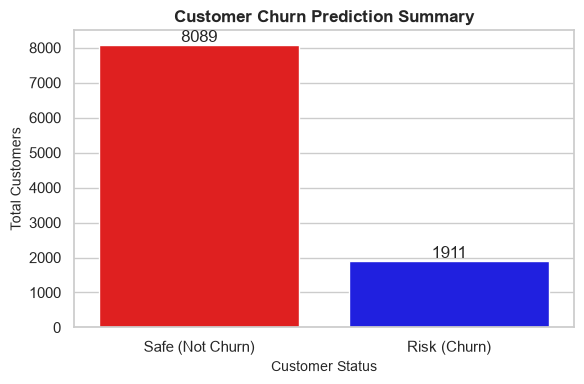

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=output_df, x='Status', palette=["red", "blue"])
plt.title('Customer Churn Prediction Summary', fontsize=12, fontweight='bold')
plt.xlabel('Customer Status', fontsize=10)
plt.ylabel('Total Customers', fontsize=10)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')
    plt.tight_layout()
plt.show()